# Compare lagrangian turbulence experiments

In [1]:
import torch
import numpy as np
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage
from typing import Dict, Any, Tuple, Optional
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from matplotlib.colors import to_rgb
from pathlib import Path
import sys
import copy
from types import SimpleNamespace

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_experiment import * 
from utils_entropy import *
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

sys.path.insert(0, str(root / '../turbulence/'))
from diagnostics import * 

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


In [6]:
# Default parameters
J = 8
Q = 3
M = 256
sigma = 3.5
nt = 40000
n1 = 5000
lam = 1e-07
n_subsample = 200
regularization = 1e-2

# data preparation 
W = DefineWavelet('Db', m=3, device=device)

# LAGRANGIAN TURBULENCE DATA 
Data = load_turbulence_1d().to(device) 
print(Data.shape, Data.device) 
n1_initial = 1024
Data = split_periodize_reshape(Data, n1_initial)

B, C, L = Data.shape
print(Data.shape) 

if M == 128: 
    scales = 3
if M == 256: 
    scales = 2
for j in range(scales):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:n1])

print('x1 shape:', x1.shape)

torch.Size([10000, 1, 1800]) cuda:0
torch.Size([10000, 1, 1024])
x1 shape: torch.Size([5000, 1, 256])


In [7]:
terms=[
    "L_6",
    "L_6_psi",
    "L_2_lowpass",
    "Scattering_Fourth_Order_Mod2_Real_Q1",
    "Scattering_Fourth_Order_Mod2_Imag_Q1",
    "Scalar_psi_gaussianK",
    "Scalar_morlet_gaussianK", 
]
base_args = SimpleNamespace(
    J=J,
    Q=Q,
    terms=terms, 
    nt=nt,
    sigma=sigma,
    interpolant='Cos',
    regularization=regularization,
    lam=lam,
    n_subsample=n_subsample,
    batch_size="", # Adjust based on your x1.shape[0] // 2
    label="",
    #timestamp="",    # Leave empty to allow the resolver to find the latest run
    n1=n1, 
    seed=0
)

In [10]:
experiments_to_compare = {
    'seed0': {
        #"timestamp": 20260717_0046,
        # 'terms': [
        #     "L_6", 
        #     "Scattering_First_Order", 
        #     "Scattering_Second_Order", 
        #     "Scattering_Fourth_Order_Mod2_Real_Q1", 
        #     "Scattering_Fourth_Order_Mod2_Imag_Q1"
        # ],
    },
    'seed30': {},

    # "n_initial_1024": {
    #     "timestamp": 20260717_0052,
    # }, 
    

    # 'without_L3': {
    #     'terms': [
    #         "Scattering_First_Order", 
    #         "Scattering_Second_Order", 
    #         "Scattering_Fourth_Order_Mod2_Real_Q1", 
    #         "Scattering_Fourth_Order_Mod2_Imag_Q1"
    #     ]
    # },
    # 'no_Imag': {
    #     'terms': [
    #         "Scattering_First_Order", 
    #         "Scattering_Second_Order", 
    #         "Scattering_Fourth_Order_Mod2_Real_Q1", 
    #     ]
    # },
    
    # Template for adding future experiments:
    # 'Custom_Experiment_Name': {
    #     'terms': [
    #         "Scattering_First_Order",
    #         # ... add or remove statistical terms here ...
    #     ]
    # },
}

In [11]:
results = {}
M = M  # Or 256, depending on the scale you are checking

for key, overrides in experiments_to_compare.items():
    # 1. Copy base args and apply the specific overrides for this experiment
    current_args = copy.copy(base_args)
    for k, v in overrides.items():
        setattr(current_args, k, v)
        
    # 2. Build the config prefix (exclude timestamp so we can search for it)
    current_args.timestamp = "" 
    config_prefix = build_config_name(current_args, M=M, include_timestamp=False)
    
    print(f"[{key}] Searching for prefix: {config_prefix}")
    
    # 3. Resolve the exact folder name (handles the timestamp matching)
    resolved_config = resolve_config_for_loading(root, config_prefix)
    
    if resolved_config:
        # 4. Load the data using your new SDE utility
        loaded_data = try_load_experiment(root, resolved_config, device)
        
        if loaded_data and loaded_data.get('loaded', False):
            results[key] = loaded_data
            print(f"  -> Successfully loaded: {resolved_config}\n")
        else:
            print("  -> Failed to read data files.\n")
    else:
        print("  -> No matching runs found in saved_results/samples.\n")

[seed0] Searching for prefix: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam1e-07_seed_0_terms2f1130a8
  -> Successfully loaded: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam1e-07_seed_0_terms2f1130a8_20260717_1508

[seed30] Searching for prefix: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam1e-07_seed_0_terms2f1130a8
  -> Successfully loaded: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam1e-07_seed_0_terms2f1130a8_20260717_1508



# 

In [12]:
# Coarse-grain or analyze the experiments
for key, res in results.items():
    theta_t = res['theta_t']
    theta_reg_t = res['Theta_reg'] # Updated to match the new return dictionary
    
    print(f"{key}:")
    print(f"  theta_t shape: {theta_t.shape}")
    print(f"  Theta_reg shape: {theta_reg_t.shape}")
    print(theta_reg_t[-1,0]) 

    

seed0:
  theta_t shape: torch.Size([39704, 203])
  Theta_reg shape: torch.Size([197, 203])
tensor(-162176.6250)
seed30:
  theta_t shape: torch.Size([39704, 203])
  Theta_reg shape: torch.Size([197, 203])
tensor(-162176.6250)


## Compute diagnostics 

torch.Size([5000, 1, 256])
torch.Size([5000, 1, 256])
Marginal histograms


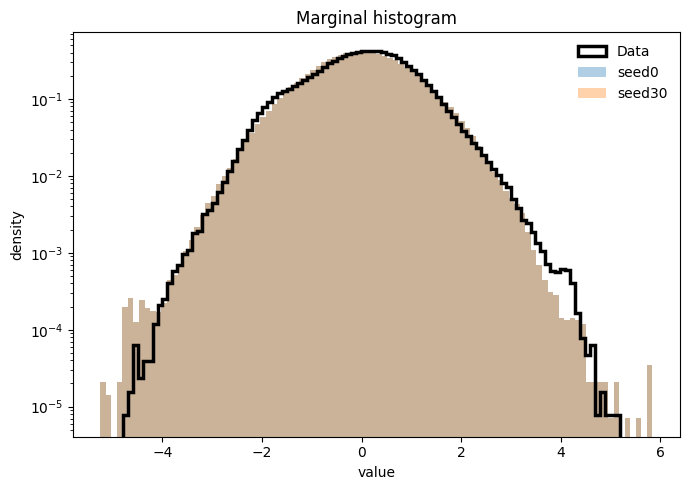

Per-band wavelet histograms (Q=3)


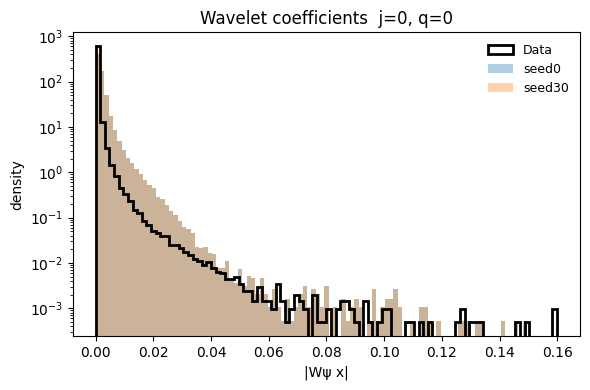

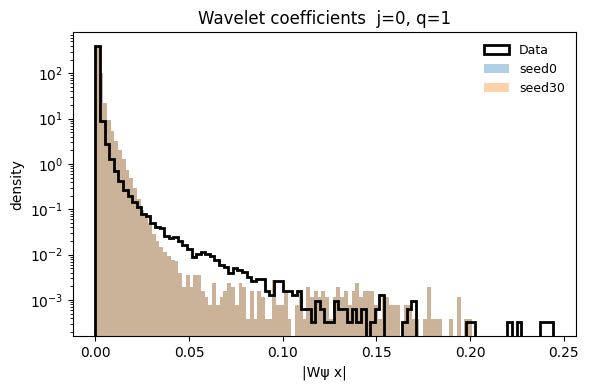

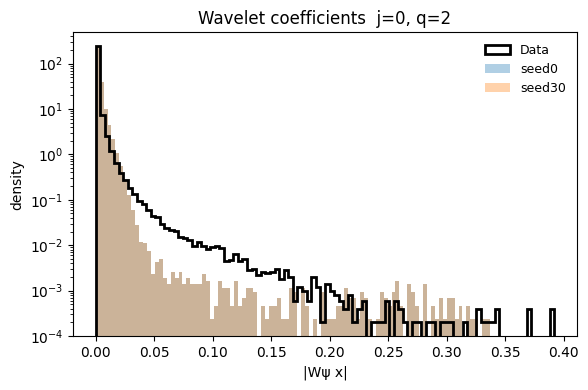

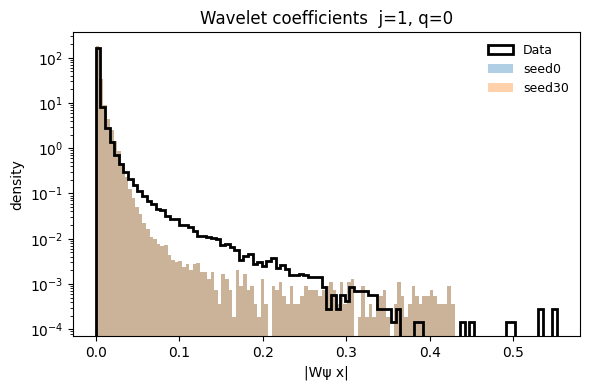

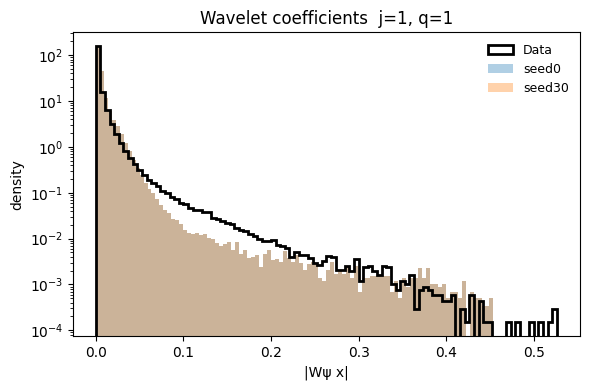

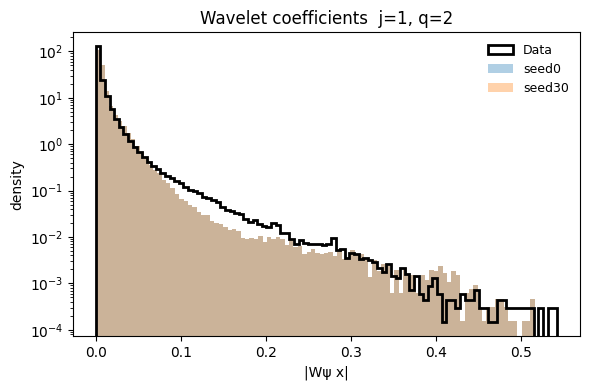

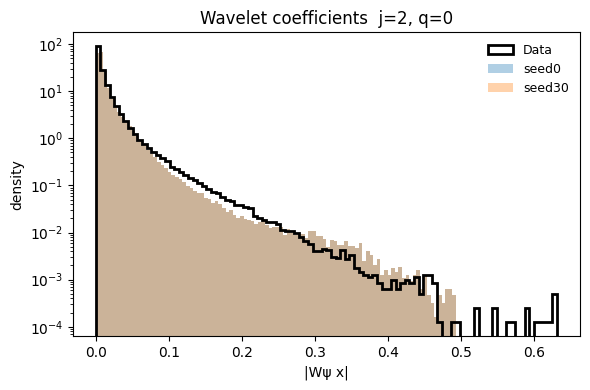

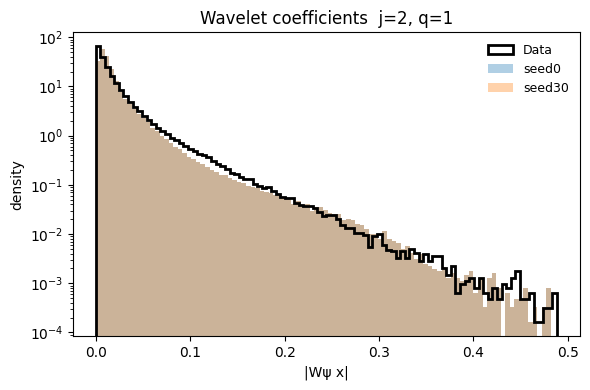

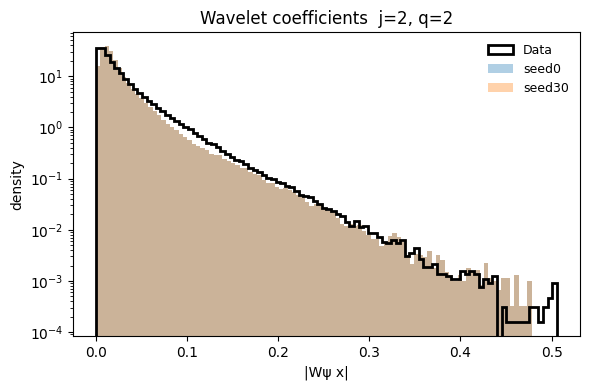

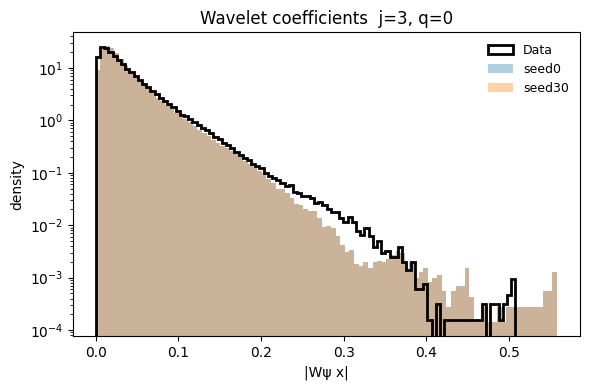

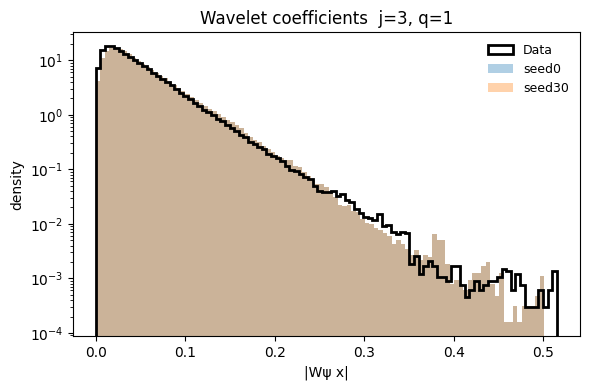

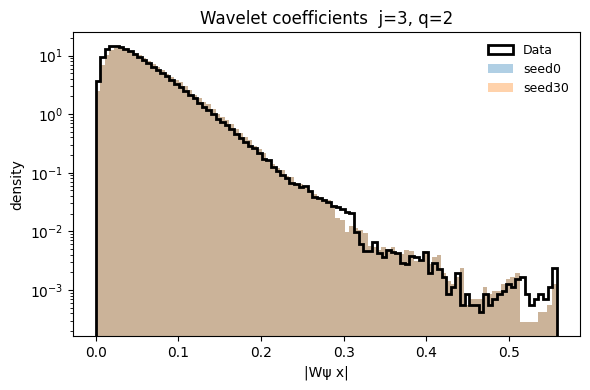

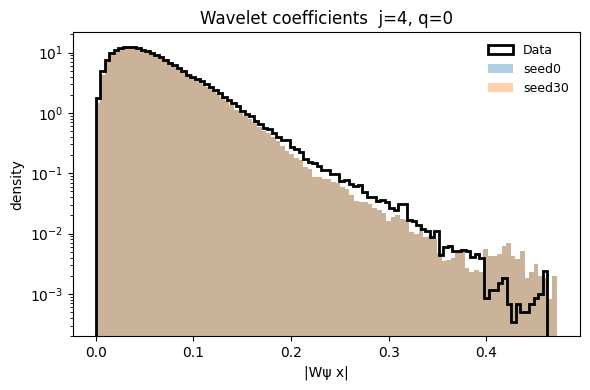

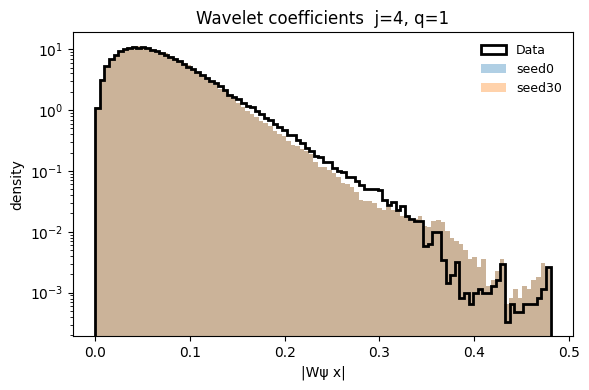

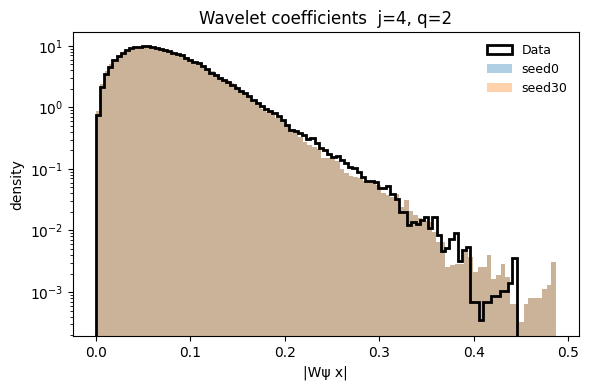

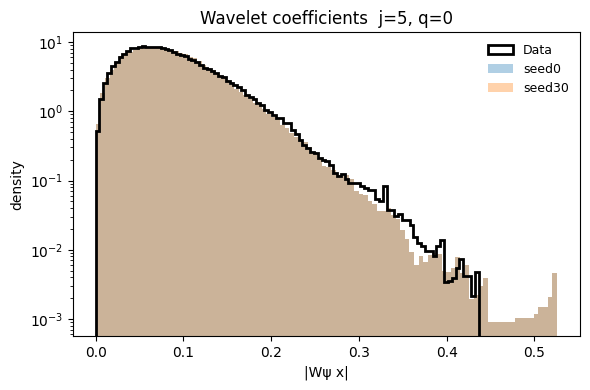

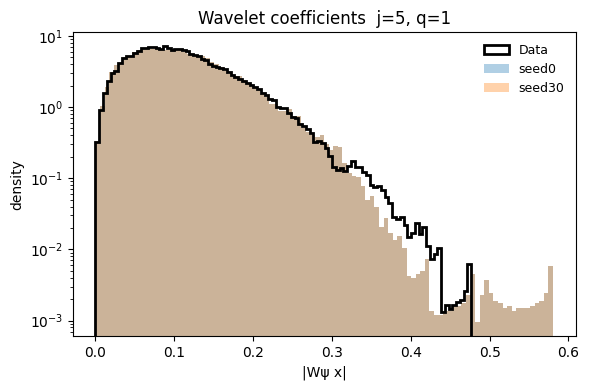

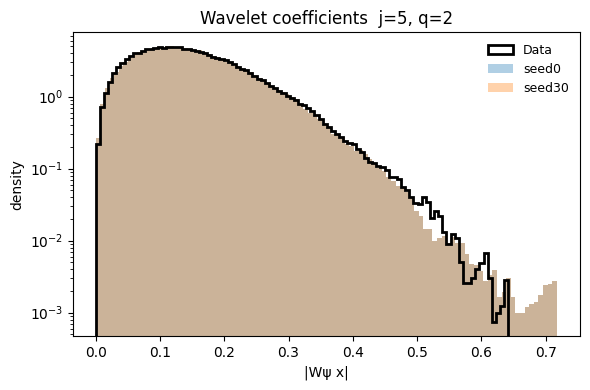

Moment matching


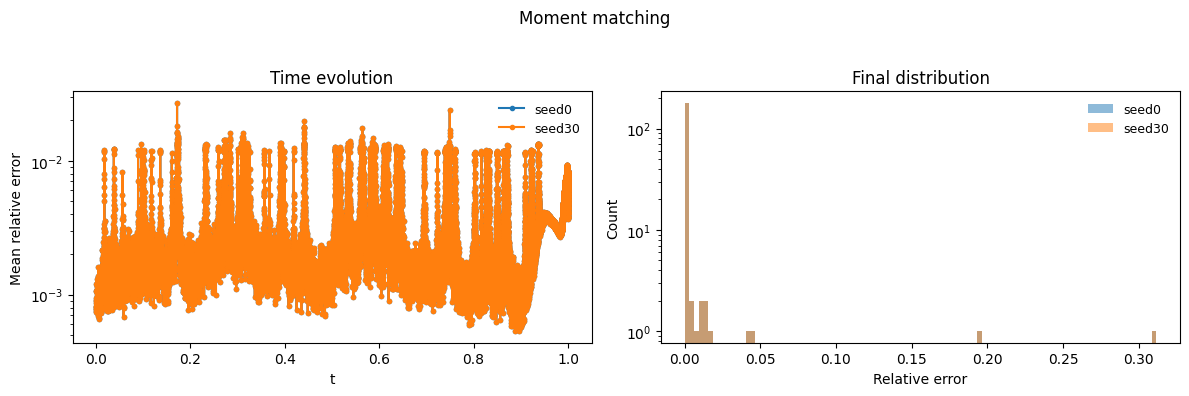

Power spectra


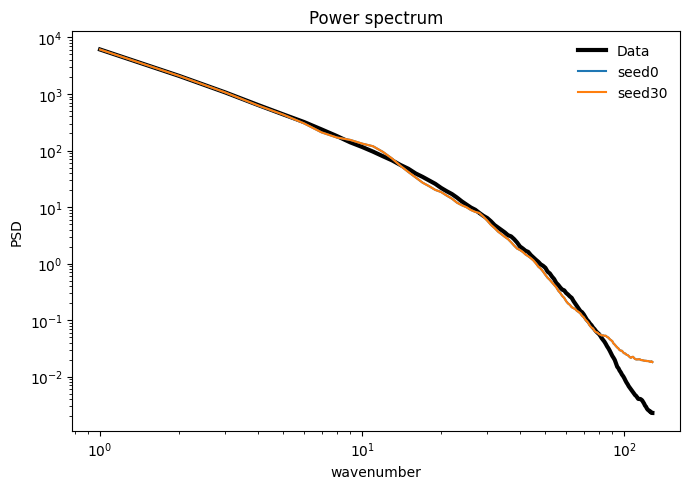

Structure functions


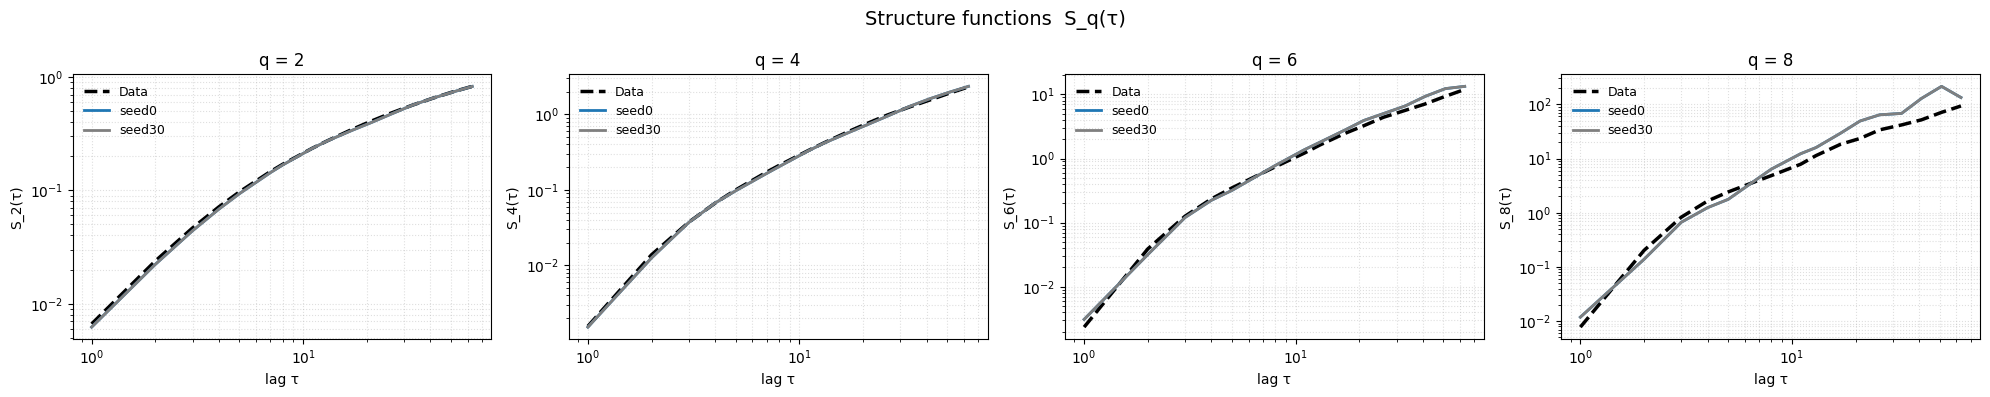

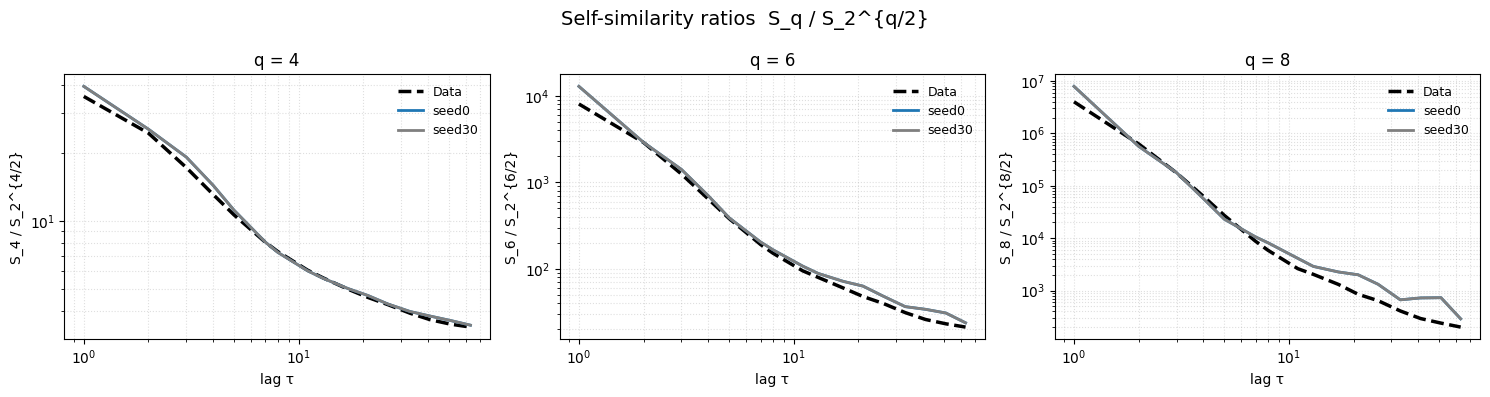

Increment PDFs


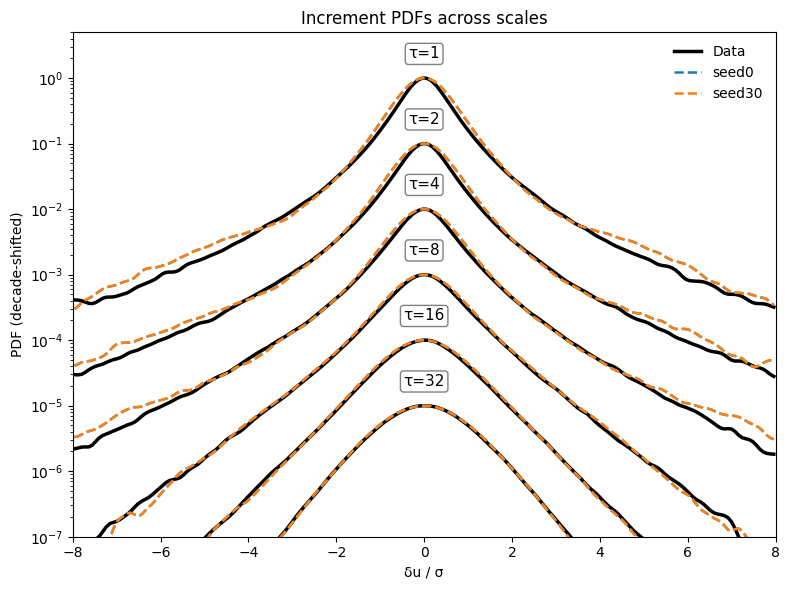

Entropy bound
seed0:
  Entropy bound: -141409.3750
  Gaussian estimation: -304.5204
seed30:
  Entropy bound: -141409.3750
  Gaussian estimation: -304.5204


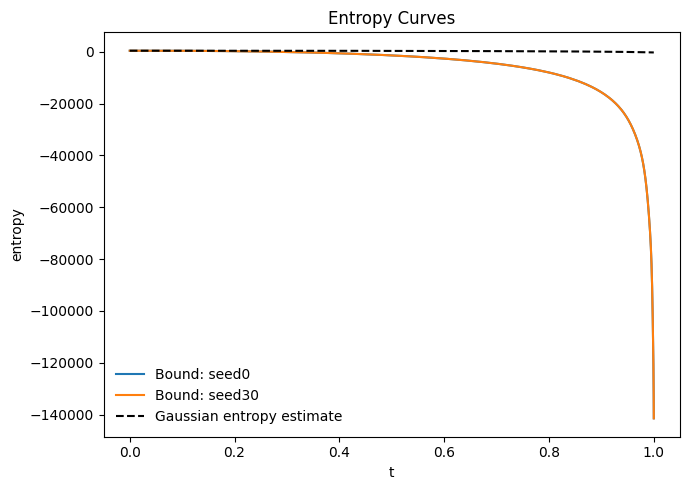

Visual comparison panels


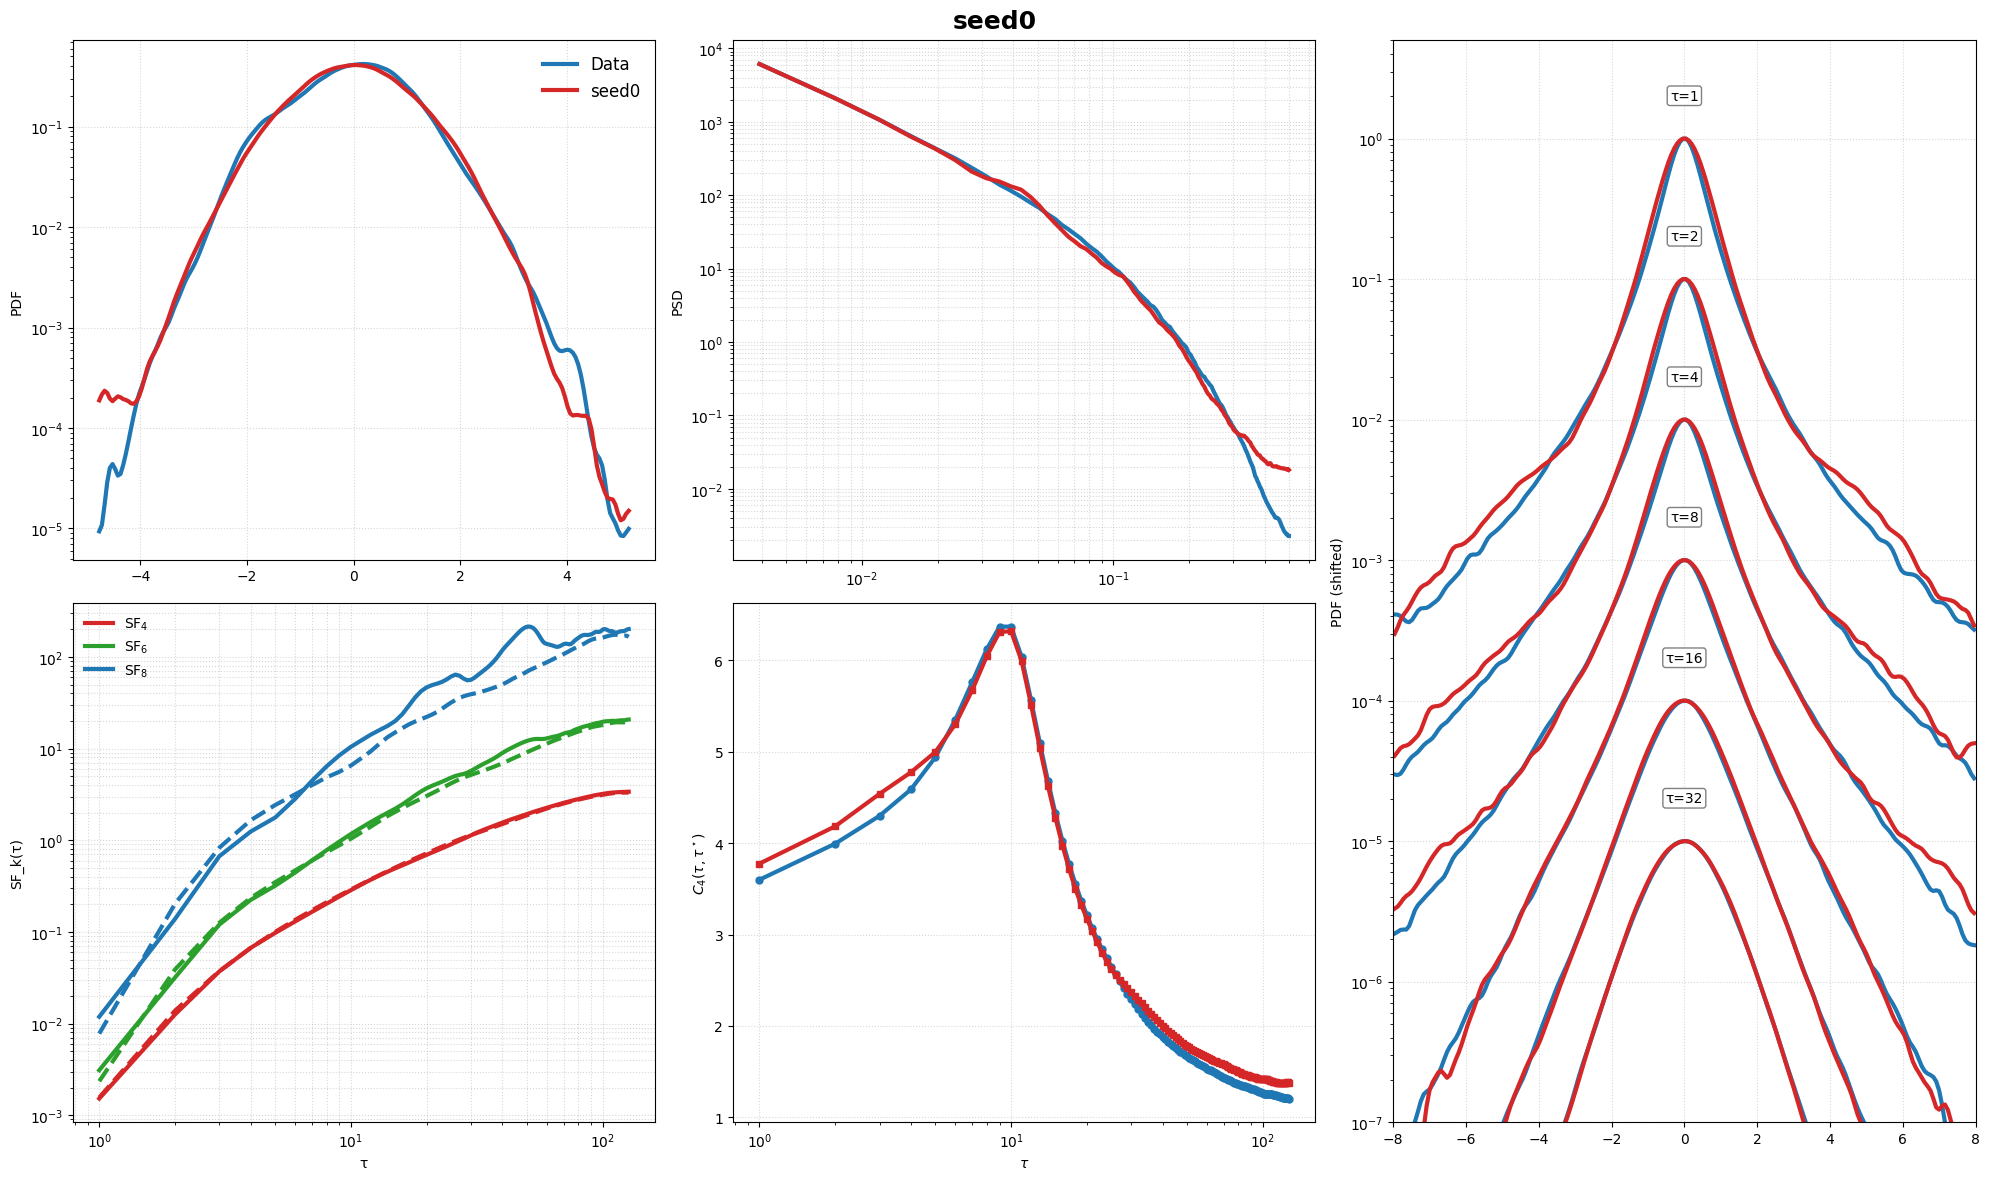

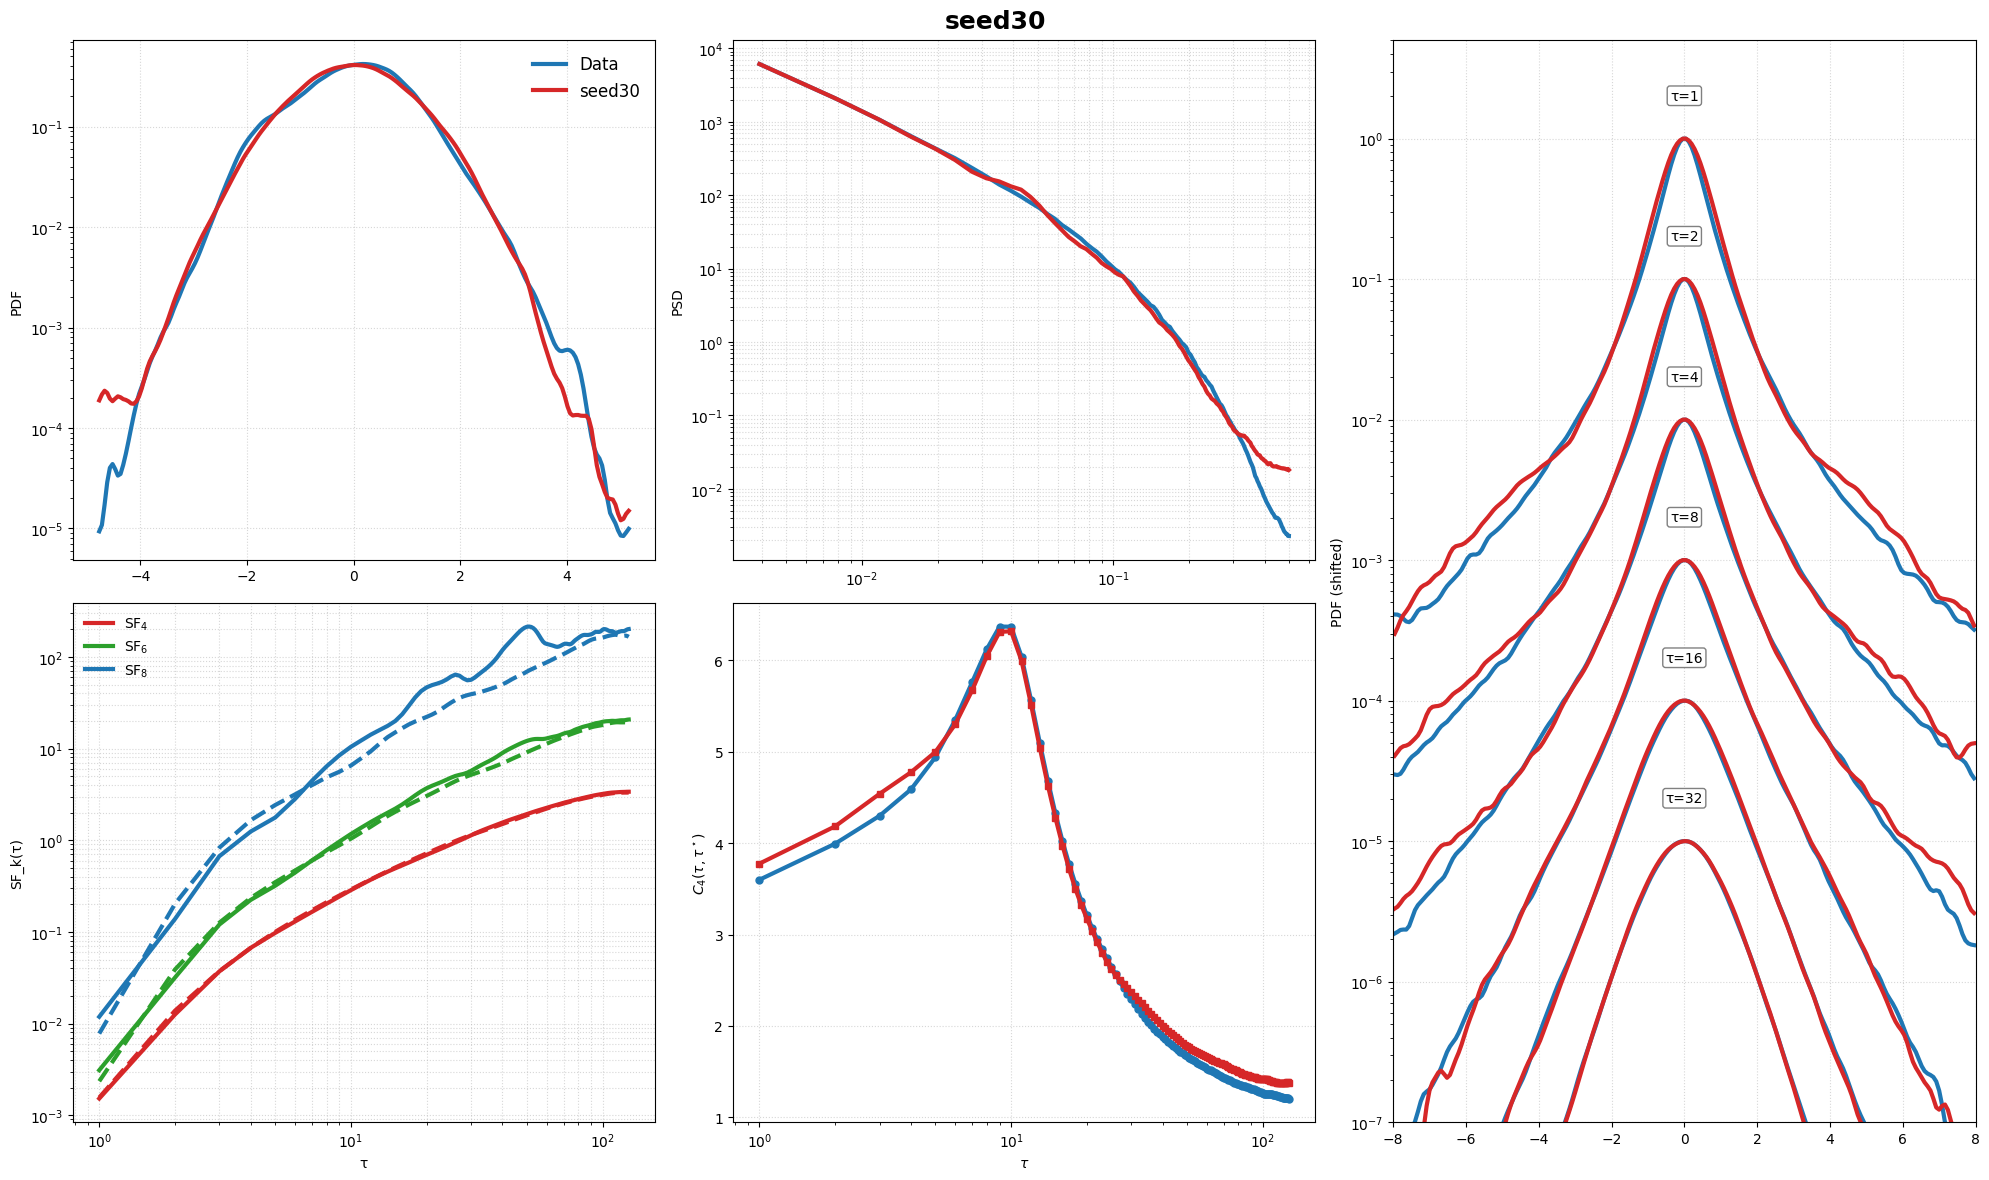

Scalar metrics
        mean_rel_error  std_rel_error  spectrum_rel_mse  wasserstein_mean  structure_rel_mse
seed0     388634.40625       0.000953          0.000002          0.042486           0.000513
seed30    388634.40625       0.000953          0.000002          0.042486           0.000513


In [13]:
# 2. Coarse-grain only the experiments that have M=256 (length 256)
for key, res in results.items():
    xt = results[key]['xt']
    print(xt.shape) 
%matplotlib inline
df = run_diagnostics(
    x1, results,
    Q=3,                          # or 3, matches your wavelet config
    show_wavelet_histograms=True,
    complex_wavelet_histograms=False,  # True -> real/imag split instead of |.|
    show_entropy_detail=False, 
)


torch.Size([5000, 1, 256])
torch.Size([5000, 1, 256])
Marginal histograms


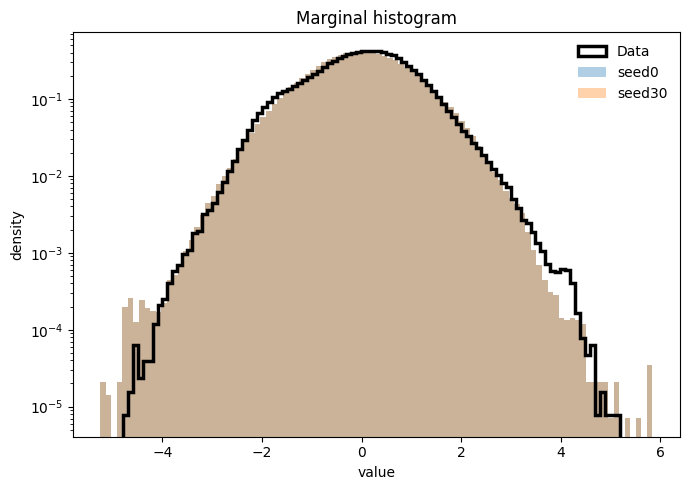

Per-band wavelet histograms (Q=1)


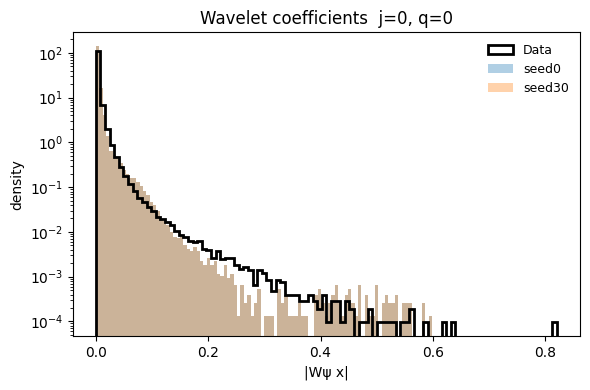

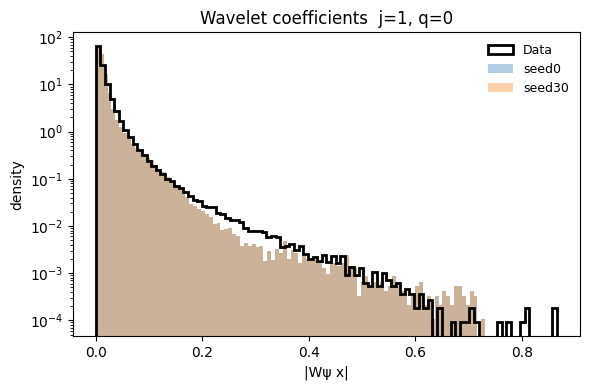

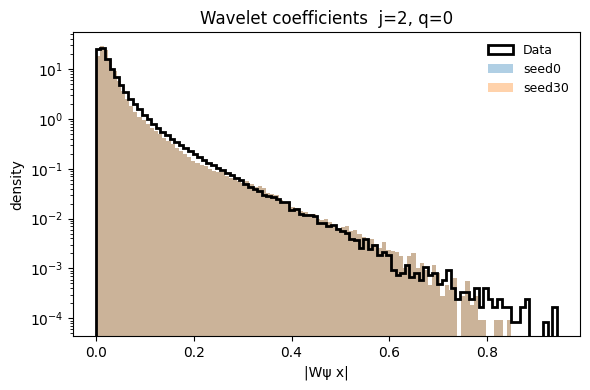

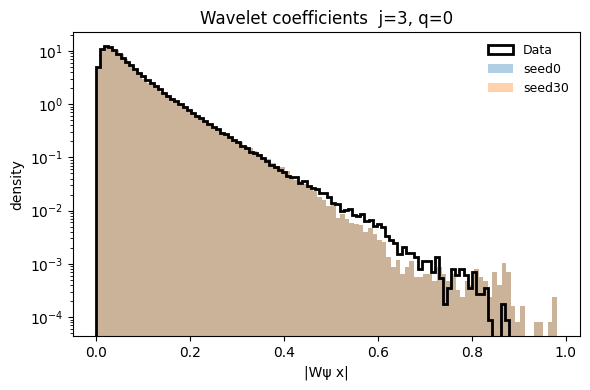

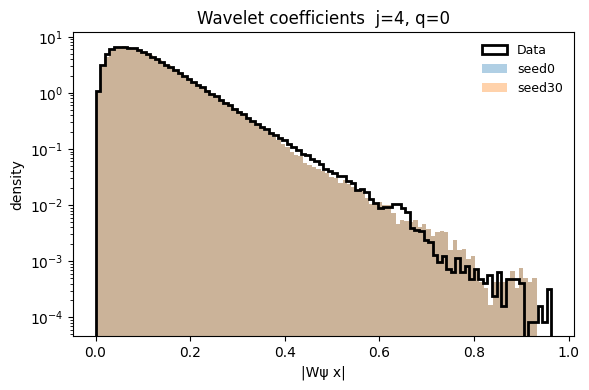

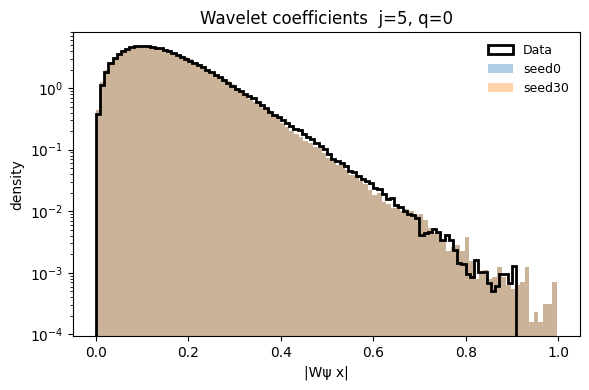

Moment matching


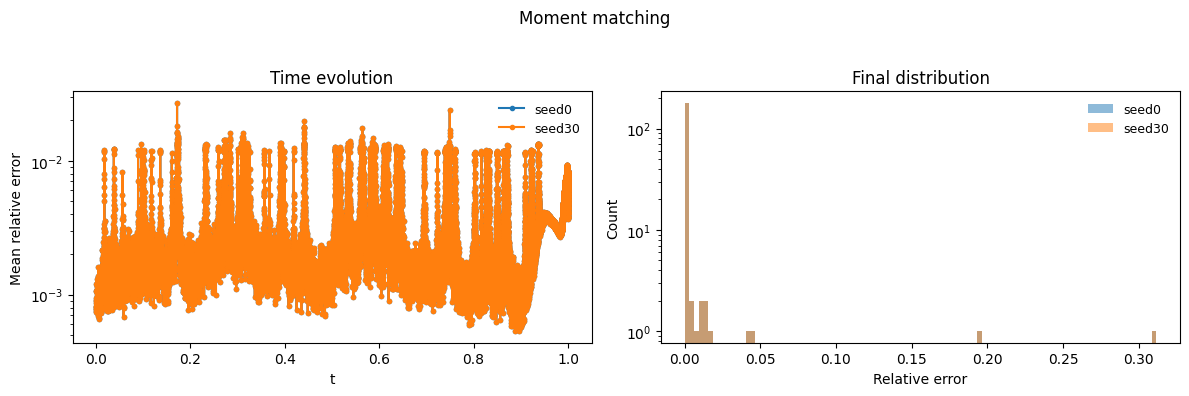

Power spectra


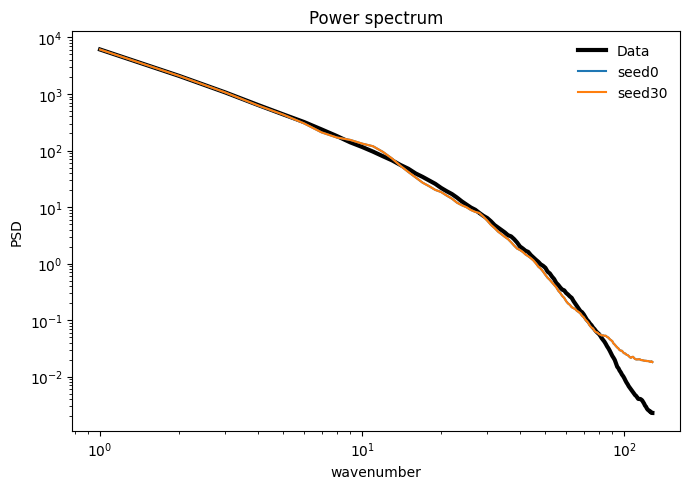

Structure functions


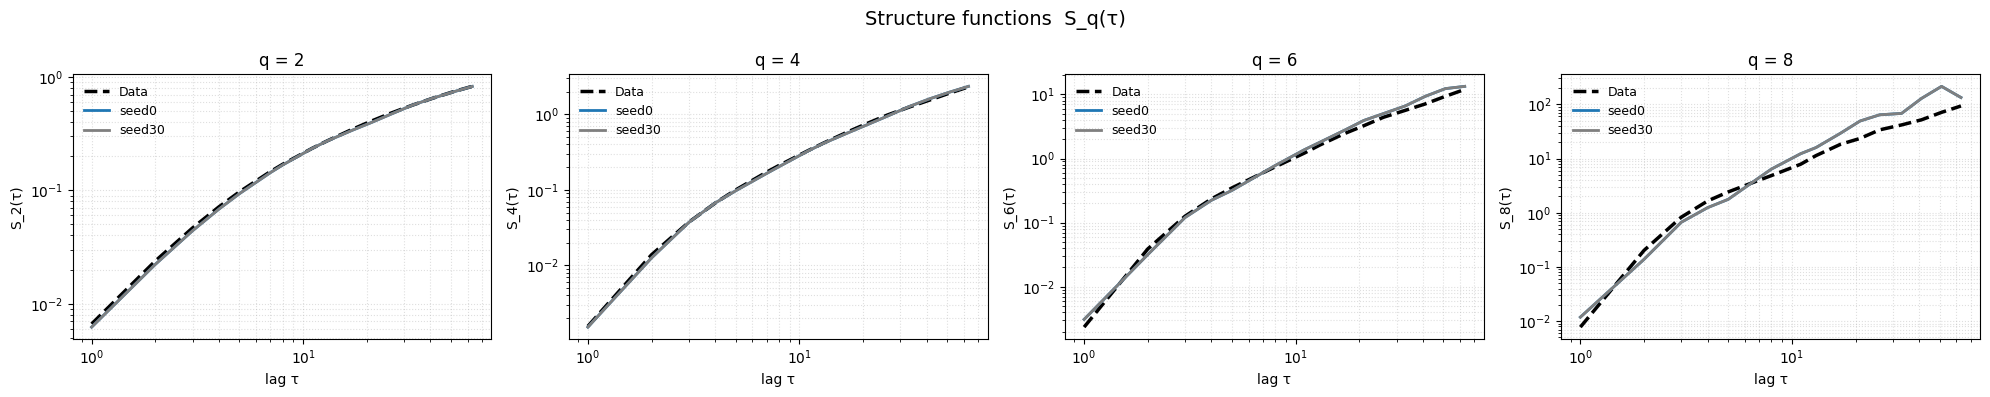

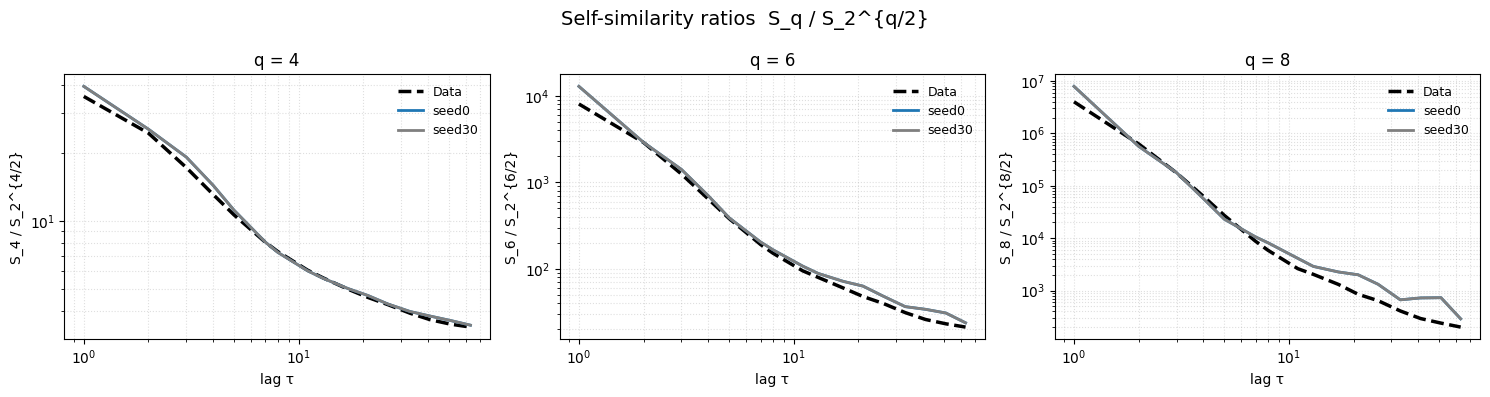

Increment PDFs


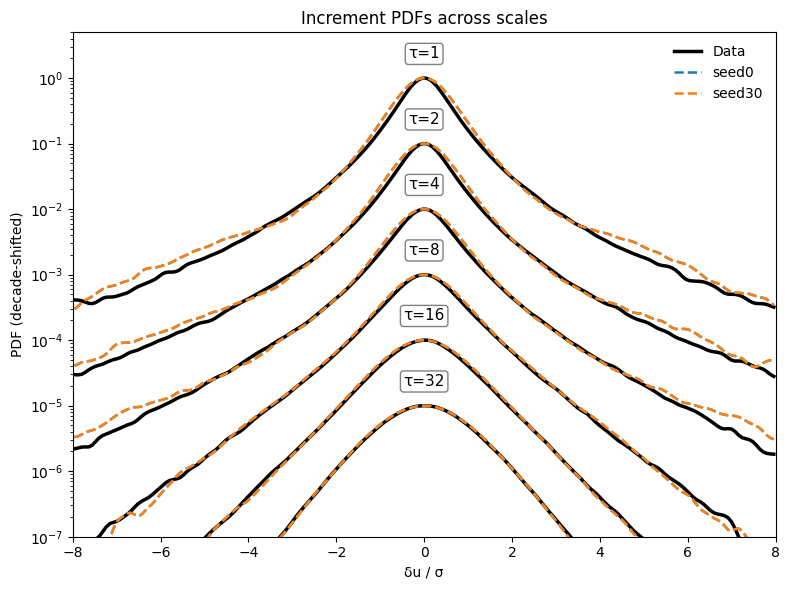

Entropy bound
seed0:
  Entropy bound: -141409.3750
  Gaussian estimation: -304.5204
seed30:
  Entropy bound: -141409.3750
  Gaussian estimation: -304.5204


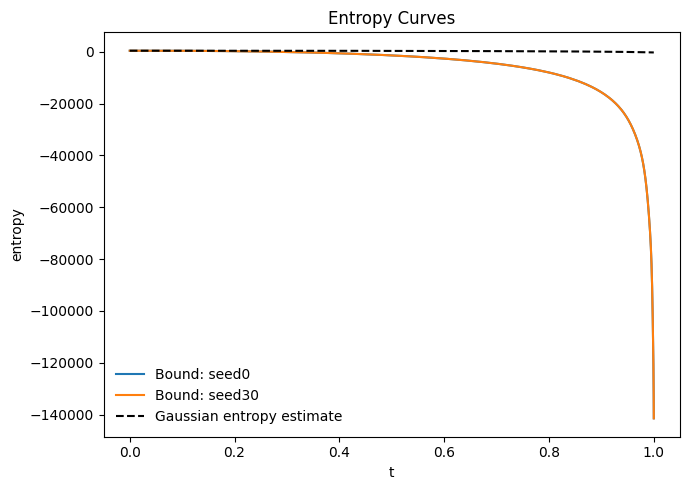

Visual comparison panels


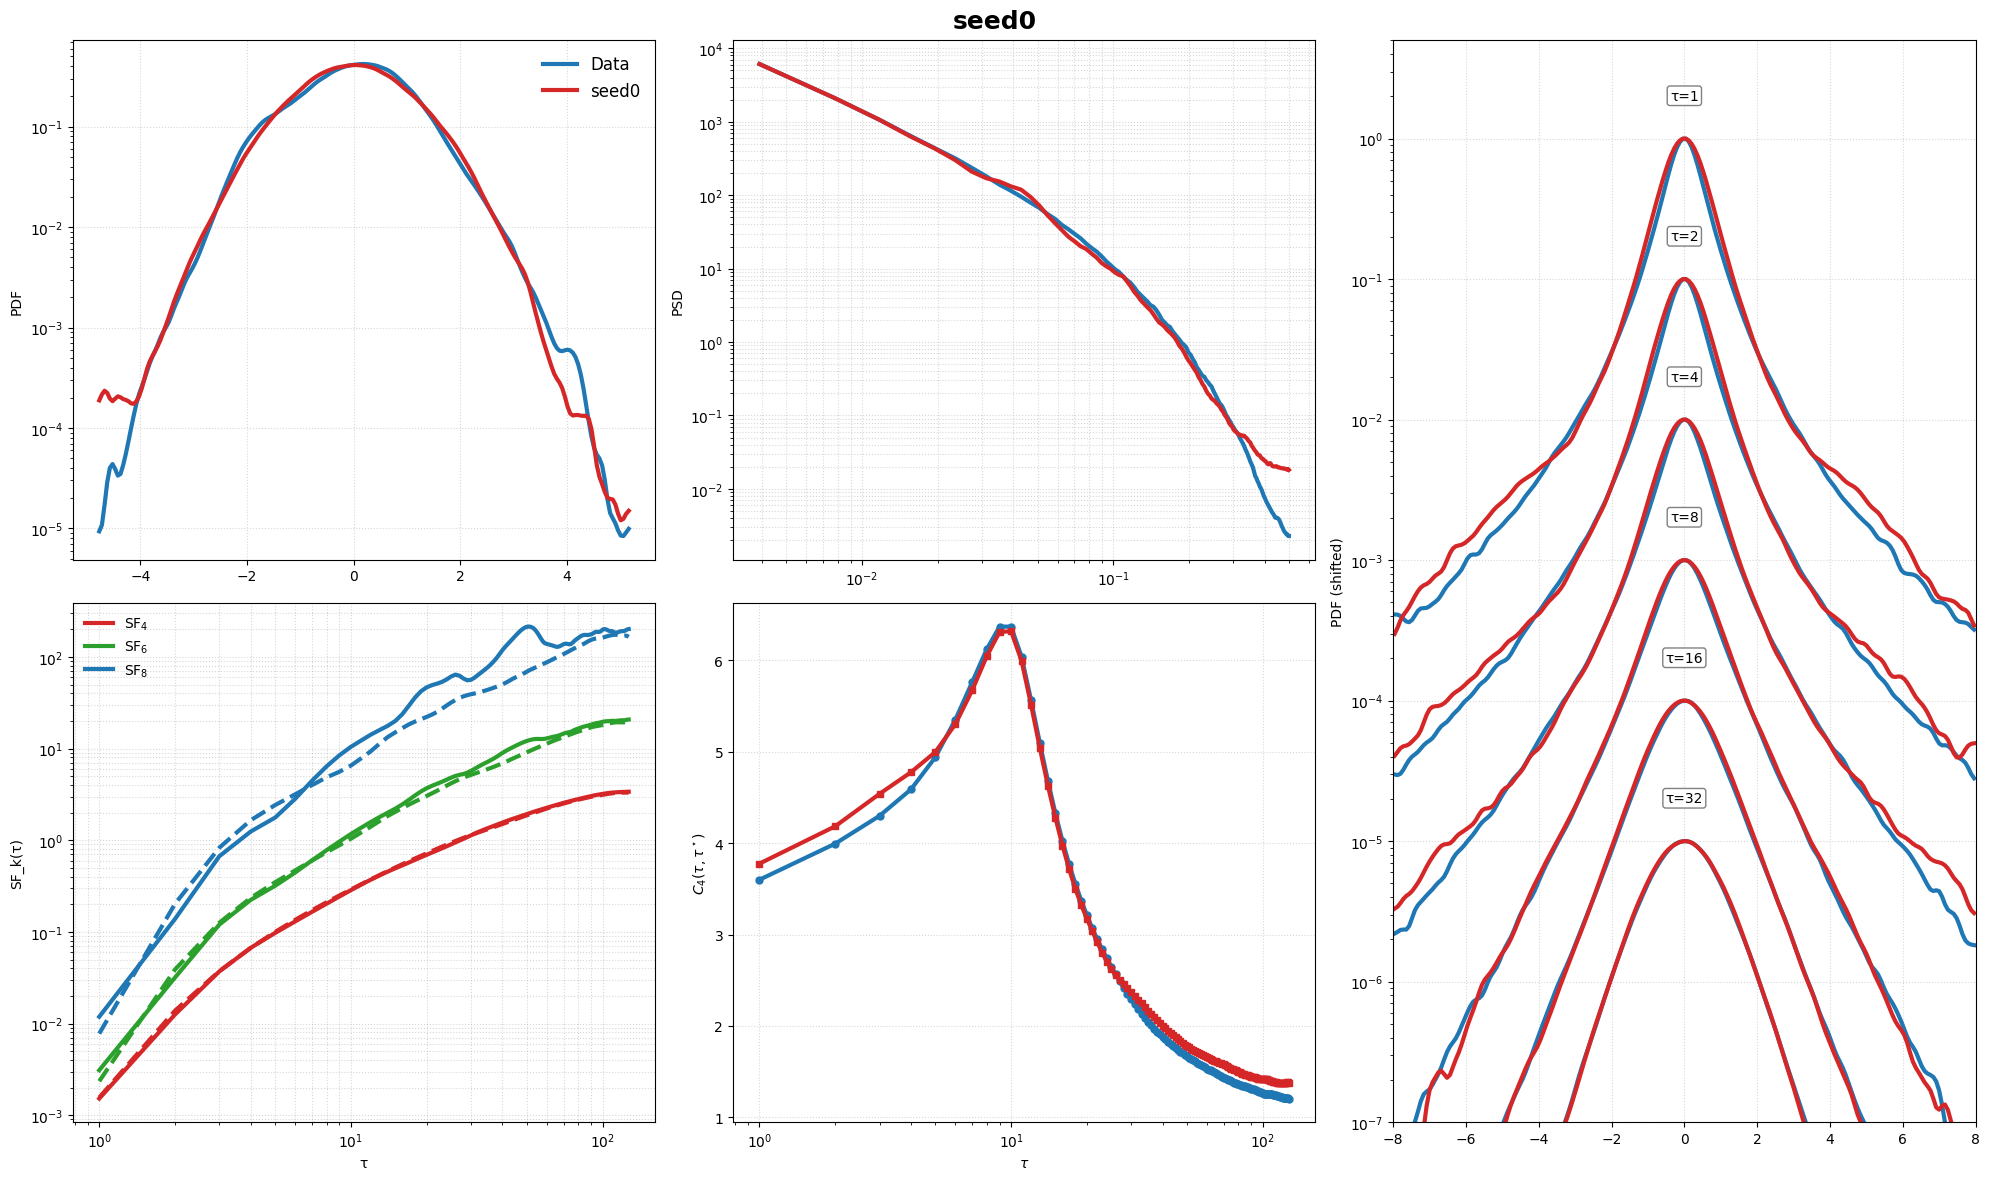

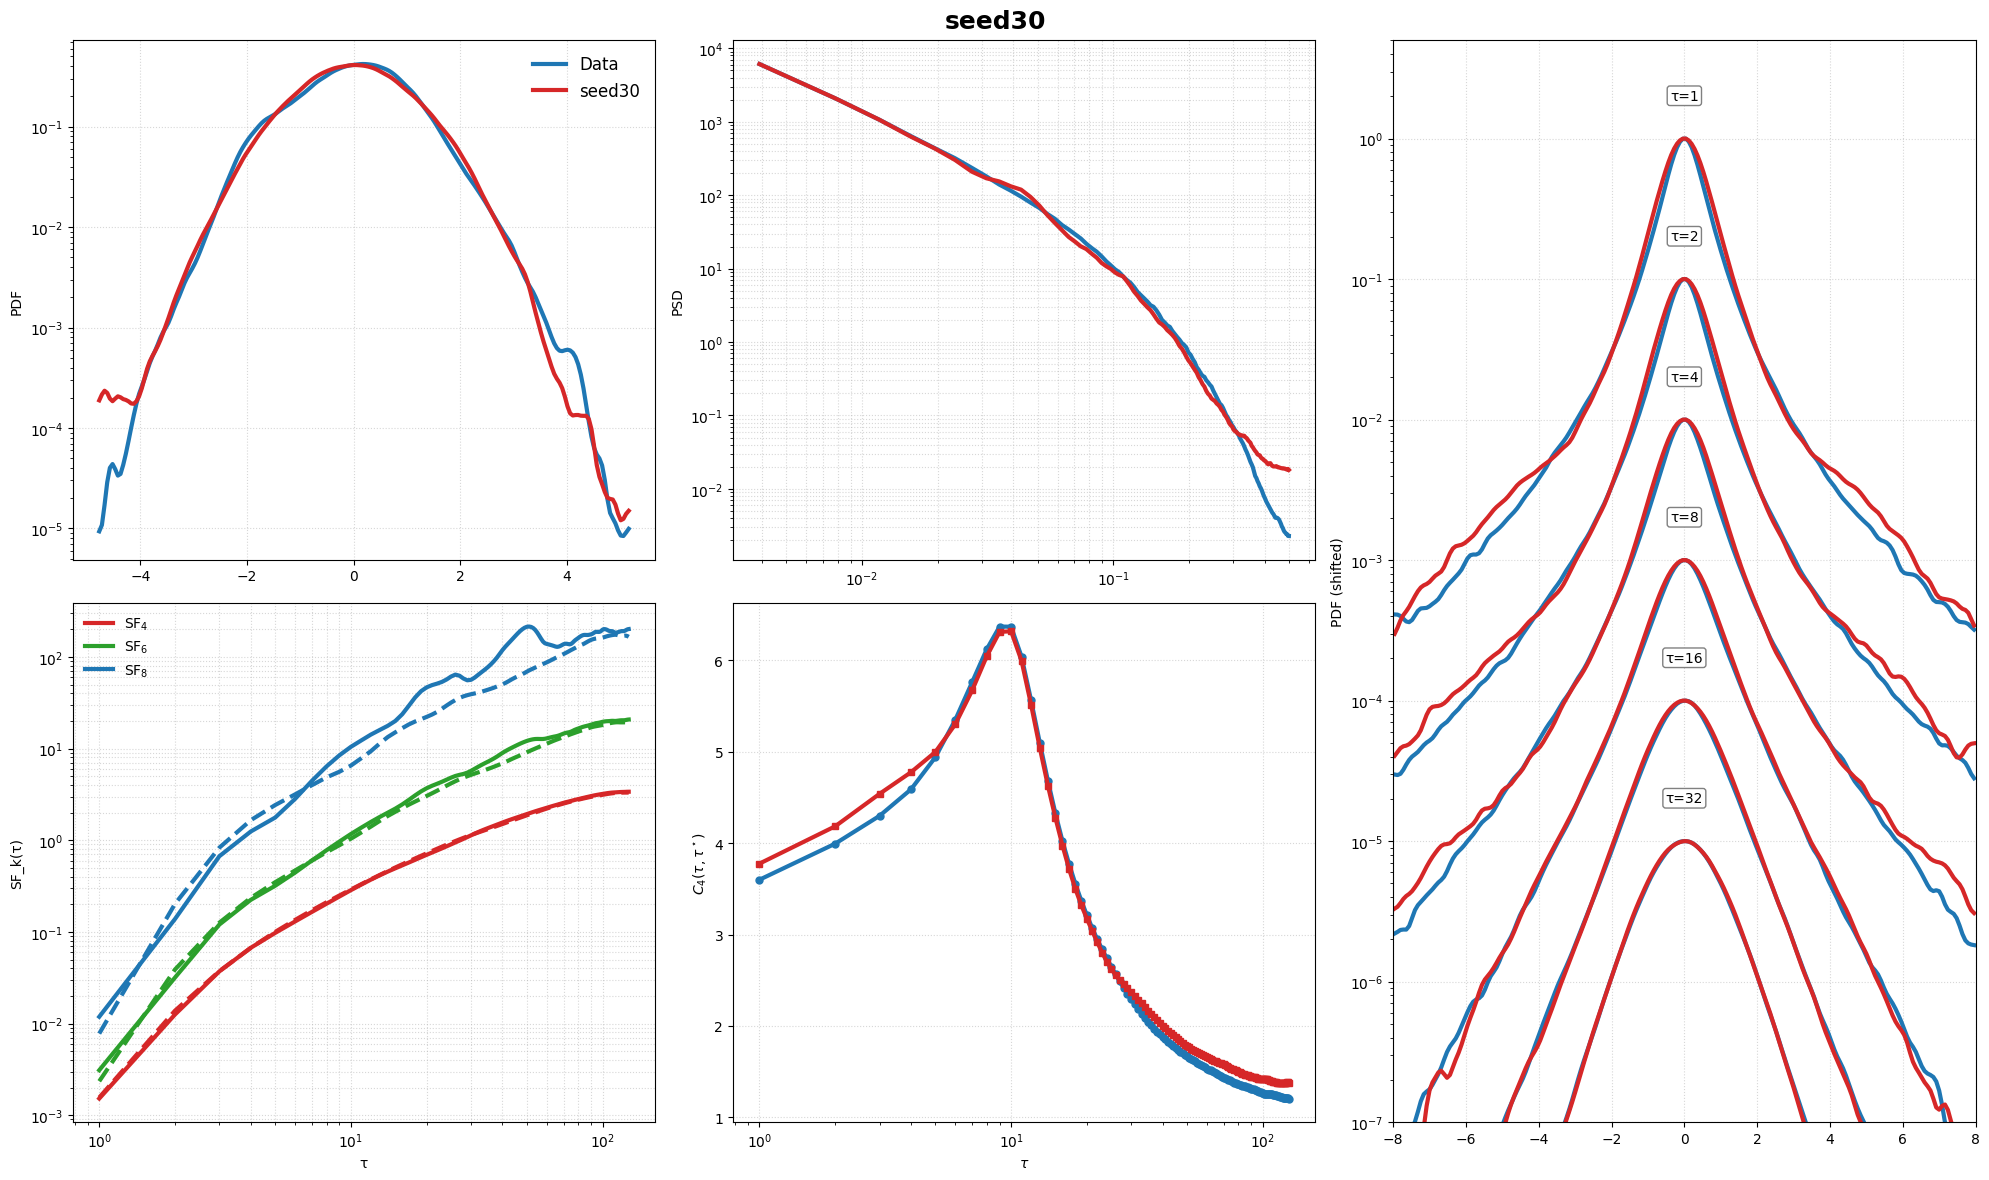

Scalar metrics
        mean_rel_error  std_rel_error  spectrum_rel_mse  wasserstein_mean  structure_rel_mse
seed0     388634.40625       0.000953          0.000002          0.042486           0.000513
seed30    388634.40625       0.000953          0.000002          0.042486           0.000513


In [14]:
# 2. Coarse-grain only the experiments that have M=256 (length 256)
for key, res in results.items():
    xt = results[key]['xt']
    print(xt.shape) 
%matplotlib inline
df = run_diagnostics(
    x1, results,
    Q=1,                          # or 3, matches your wavelet config
    show_wavelet_histograms=True,
    complex_wavelet_histograms=False,  # True -> real/imag split instead of |.|
    show_entropy_detail=False,
)


## Flatness ratio

Computing structure functions for 24 lags...
Computing structure functions for 24 lags...


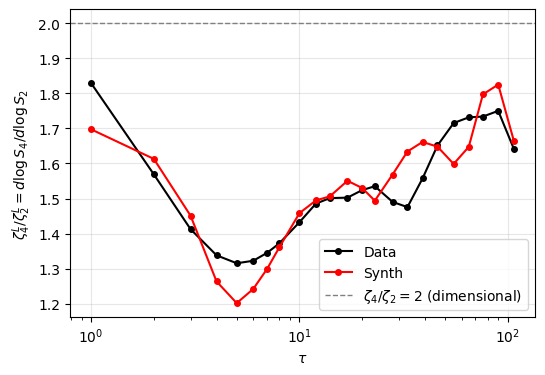

Loaded structure functions from cache!
Computing structure functions for 24 lags...


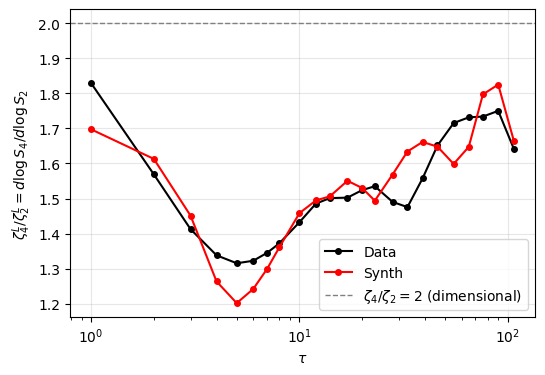

In [15]:
for key, res in results.items(): 
    # scaling exponent ratio 
    scaling_exponent_ratio_compare(x1, results[key]["xt"], 30, kill_points=1)

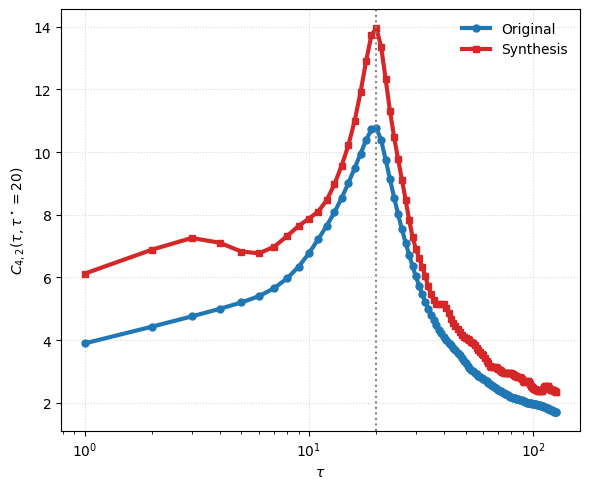

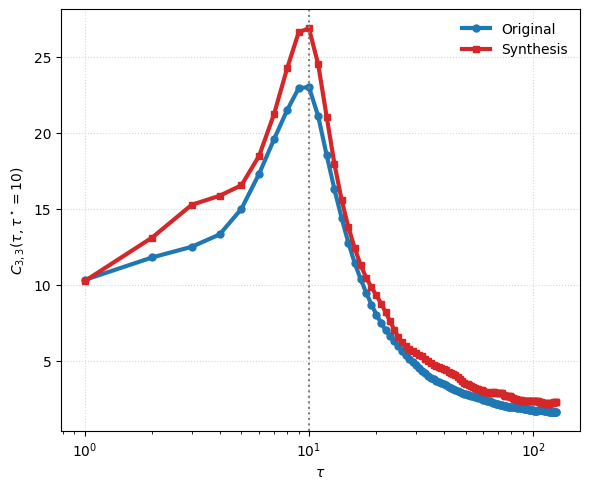

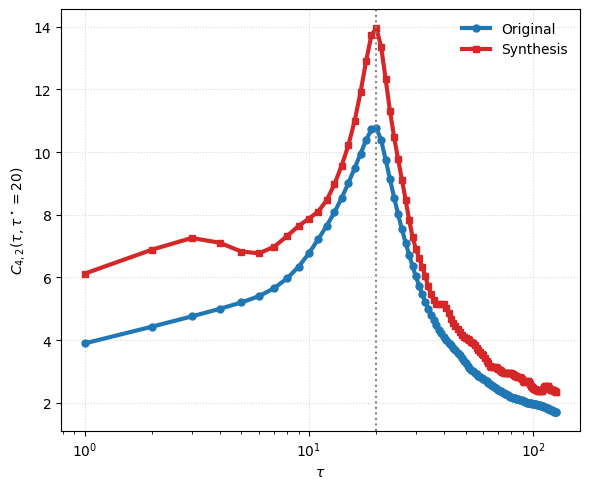

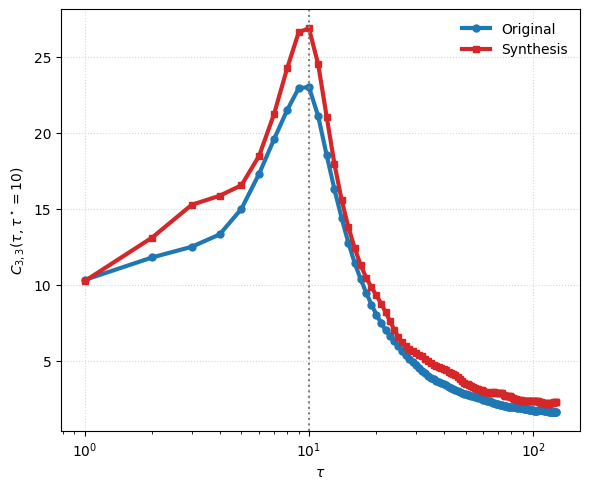

In [16]:
for key, res in results.items(): 
    %matplotlib inline 
    C42_plot(x1, results[key]["xt"]) 
    C6_plot(x1, results[key]["xt"], 10) 

## Time asymmetry

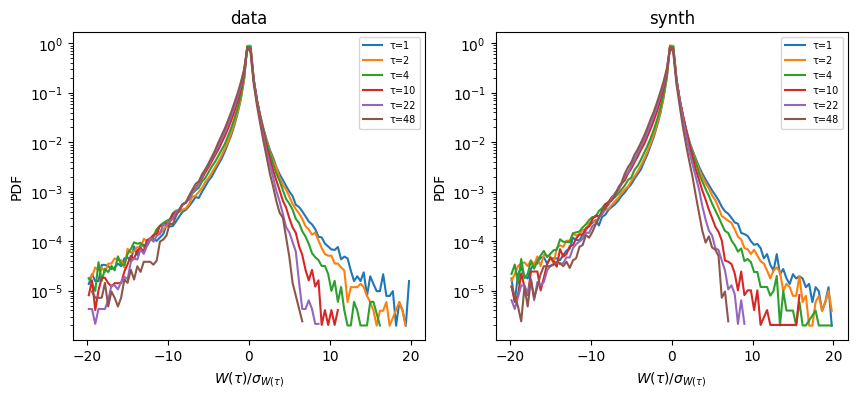

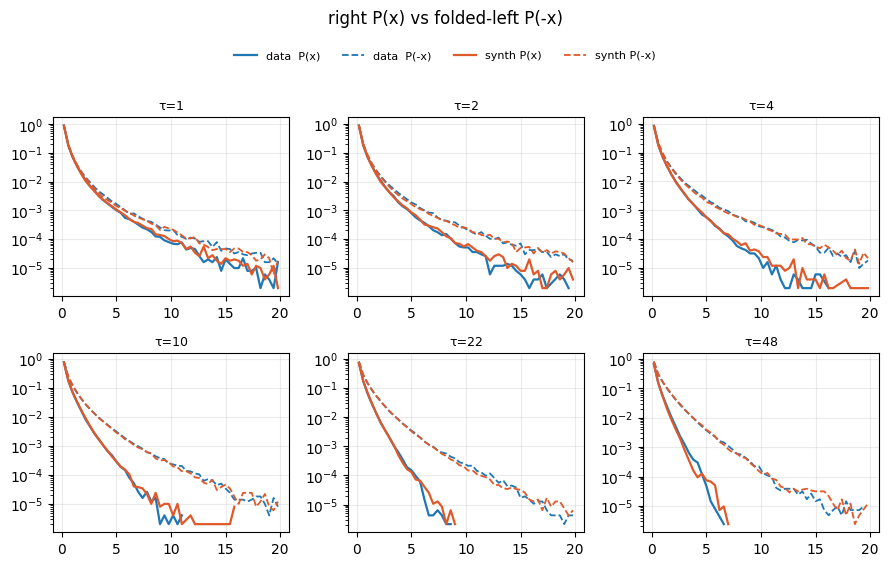

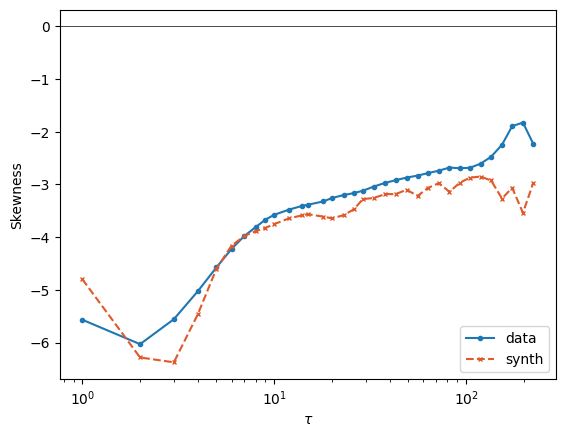

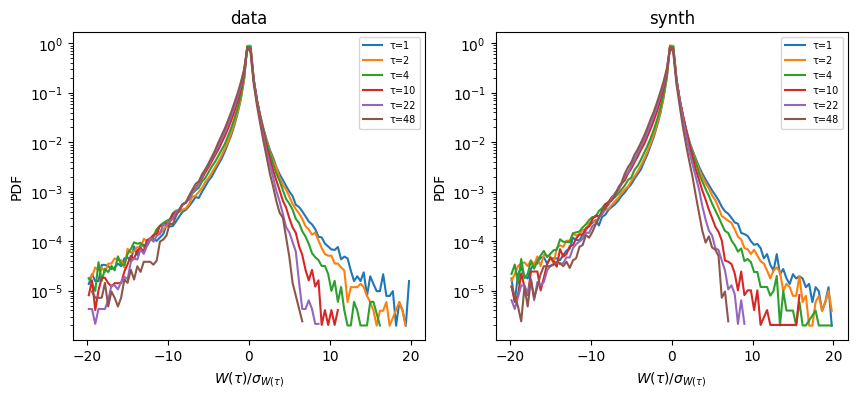

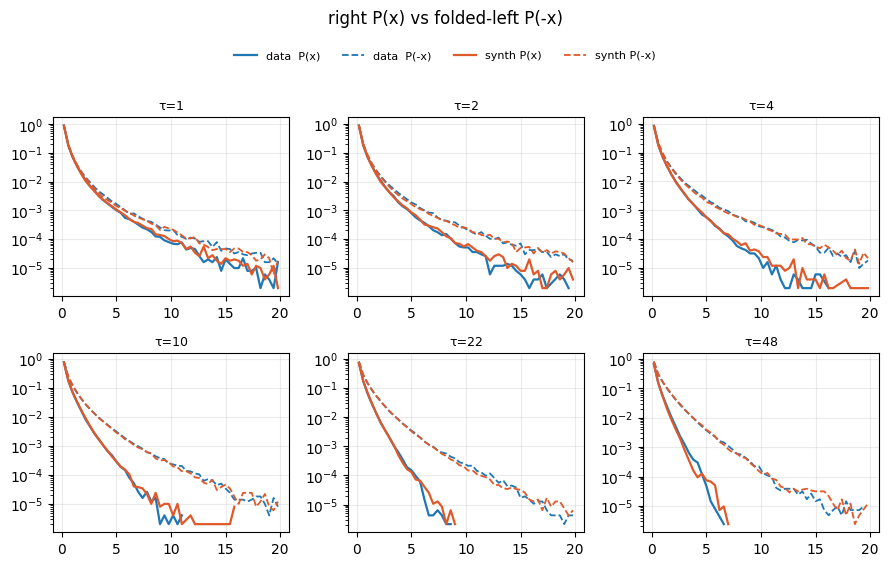

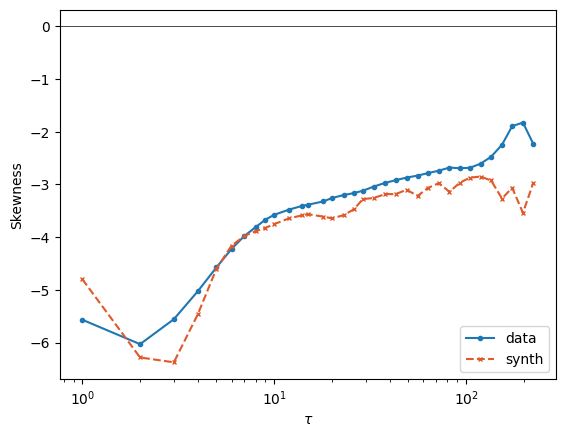

In [17]:
for key, res in results.items():
    T = x1.shape[-1]
    taus = logspaced_taus(50, num_points=6)              # positive only, for PDFs
    pdf_data  = pdf_energy_increments(x1, taus, mode="power")
    pdf_synth = pdf_energy_increments(results[key]["xt"], taus, mode="power")
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plot_pdf_panel(pdf_data, ax=axes[0], title="data")
    plot_pdf_panel(pdf_synth, ax=axes[1], title="synth")

    plot_pdf_folded_grid(pdf_data, pdf_synth, title="right P(x) vs folded-left P(-x)")
    
    fig2, ax2 = plt.subplots()
    plot_skewness_comparison(x1, results[key]["xt"], ax=ax2)   # positive-only log-x taus by default

## Negentropy time=1

In [12]:
import re

def _sigma_from_label(label: str) -> float:
    """Extract the numeric sigma value from a label like 'sigma = 20.0'."""
    m = re.search(r'sigma\s*=\s*([0-9.]+)', label)
    if m is None:
        raise ValueError(f"Could not parse sigma from label: {label!r}")
    return float(m.group(1))



def _entropy_bound_beforefinal(x_ref, dH_t_bound, t_used, nt, last_point):
    """Final-time entropy bound H_sigma* = H(p_0) + cumulative integral of dH."""
    dH_t_bound = dH_t_bound.detach().cpu()
    t_used = t_used.detach().cpu()
    nt_val = nt if nt is not None else t_used.shape[0]

    d = x_ref.shape[-2] * x_ref.shape[-1]
    H_p_0 = (np.log(2 * np.pi) + 1) * d / 2
    H_t_bound_full = dH_t_bound.cumsum(0) / nt_val + H_p_0

    # Guard against dH_t_bound/t length mismatch (same issue as plot_entropy_curves)
    min_len = min(t_used.shape[0], H_t_bound_full.shape[0])
    H_final = H_t_bound_full[min_len - last_point].item()
    return H_p_0, H_final, d


def plot_negentropy_convergence(
    x_ref: torch.Tensor,
    results: Dict[str, Dict],
    last_point=1,
    nt: Optional[int] = None,
) -> pd.DataFrame:
    """
    Reproduce Fig. 7 style plots across a sweep of sigma experiments:
      (a) ΔH_σ* = H(p_0) - H_σ*         vs sigma^2
      (b) d^-1 (H_σmax* - H_σ*)         vs sigma^2, log-log, with sigma^-2 reference
    Requires >=2 experiments, each with a 'sigma = <value>' label.
    """
    sigmas, H_finals, ds = [], [], []
    H_p_0 = None
    for key, res in results.items():
        sigma_val = _sigma_from_label(key)
        t_used = results[key]['t']
        dH_t_bound = results[key]['dH_t_bound']
        print(dH_t_bound) 
        H_p_0, H_final, d = _entropy_bound_beforefinal(x_ref, dH_t_bound, t_used, nt, last_point)
        sigmas.append(sigma_val)
        H_finals.append(H_final)
        ds.append(d)

    sigmas = np.array(sigmas)
    H_finals = np.array(H_finals)
    d = ds[0]  # assumes same dimensionality across all experiments

    order = np.argsort(sigmas)
    sigmas, H_finals = sigmas[order], H_finals[order]
    sigma2 = sigmas ** 2
    negentropy = H_p_0 - H_finals

    # Reference run: largest sigma in the sweep
    idx_max = np.argmax(sigmas)
    H_max = H_finals[idx_max]
    conv = np.abs(H_max - H_finals) / d

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # (a) negentropy vs sigma^2
    axes[0].plot(sigma2, negentropy, 'o--', color='tab:blue')
    axes[0].set_xlabel(r'$\sigma^2$')
    axes[0].set_ylabel(r'$\Delta H_*^\sigma$')
    axes[0].set_title('Negentropy estimate')
    axes[0].grid(True, ls=':', alpha=0.4)

    # (b) convergence vs sigma_max, log-log (drop the sigma_max point: diff = 0)
    mask = np.arange(len(sigmas)) != idx_max
    axes[1].loglog(sigma2[mask], conv[mask], 'o', color='tab:blue', label='data')

    x_line = np.geomspace(sigma2[mask].min(), sigma2[mask].max(), 50)
    c = conv[mask][0] * sigma2[mask][0] ** 2  # anchor sigma^-2 line to first point
    #axes[1].plot(x_line, c / x_line ** 2, '-', color='tab:blue',linewidth=1.5, label=r'$\sigma^{-2}$')

    axes[1].set_xlabel(r'$\sigma^2$')
    axes[1].set_ylabel(r'$d^{-1}(H_*^{\sigma_{\max}} - H_*^\sigma)$')
    axes[1].set_title(fr'Convergence ($\sigma^2_{{\max}}$={sigma2[idx_max]:.2g})')
    axes[1].legend(frameon=False, fontsize=9)
    axes[1].grid(True, which='both', ls=':', alpha=0.4)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame({
        'sigma': sigmas, 'sigma2': sigma2,
        'H_final': H_finals, 'negentropy': negentropy,
        'convergence': conv,
    })

In [14]:
# experiments = {
#     f'sigma_{s}': {
#         'label': f'sigma = {s}',
#         'config': f'jetsynth_Re_number{Re_number}_M{M}_J{J}_Q{Q}_sigma{s}_nt10000_n1_{n1}_lam{lam}',
#     }
#     for s in [0.1, 1.0, 2.0, 3.5, 10.0]
# }

df = plot_negentropy_convergence(x1, results, last_point=50)
df

<class 'ValueError'>: Could not parse sigma from label: 'with_L3'

## Theta scaling 

In [37]:
filters = return_Filters(M, J, 1, device=device)